# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
4. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [31]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [32]:
# Load the dataset
df = pd.read_csv('/Users/libraryfree/Desktop/MachineLearning/CausalInf_project/sequential_mediation_dataset.csv')


## Model Choice

The goal is to predict the score of coping, based on the other features (educational_intervention, social_support_enhancement, mental_health_score, socioeconomic_status, school_quality_scor, baseline_cognitive_score, (random_noise)). 
1. Lineare Regression: finds a linear relationship between features and target with different weight, while it minimises the MSE
2. Random Forest: is creating a specific amount of trees and takes the average of all. so good for non-linearites, inter-dependencies, so takes the multi-factor problem of the prediciton of coping into account. 
3. Gaussian Process Regressor: interpolates smoothly between neighbooring points. So treats every feature equally. Random noise will be as important as mental health. Probably not working for this
4. DecisionTreeRegeressor: follows each features' best path no next feature, in terms like: best if-than-way 
5. Ridge: similar to LinearRegression, but can minimize some features, if too high values. Prevents overdomination of certain features
6. Lasso: similar to Linear Regression, but sets unimportant features to zero
7. ElasticNetCV: is a combination of Ridge and Lasso, and CV (cross validation) means, it gets tested multiple times on different train splits (folds)
8. SGDRegressor: learn by try and error, not by formula. So it is fast and good for big dataset. Probably to sophisticated for this small data
10. Gradient Boosting Regressor: minimizing error from last tree with new tree
10. Pipeline
11. DAG

In [3]:
# Feature selection
from sklearn.linear_model import LinearRegression
# First selection: without random noise (because the result wouldn't offer a direct interpretation), 
# and without 'educational_intervention', as it is not contionous values, but 0 or 1
x = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y = df['coping_strategy_improvement']

# Splitting the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Implementationi of baseline model
# Initialize and train the baseline model: 1. Linear Regression
model = LinearRegression()
model.fit(x_train, y_train)

#Predictions
y_pred=model.predict(x_test)

#Evaluations
r2_1=r2_score(y_test, y_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_1=mean_squared_error(y_test, y_pred) #average error
mae_1 = mean_absolute_error(y_test, y_pred) #average absolute difference between calculated and real value
rmse_1 = np.sqrt(mse_1) #in original units of target, same as mse

print(f'R²: {r2_1:.3f} \nMean squared error: {mse_1:.3f} \nMean absolute error: {mae_1:.3f} \nroot mean squared error: {rmse_1:.3f}')

R²: 0.841 
Mean squared error: 0.555 
Mean absolute error: 0.592 
root mean squared error: 0.745


In [4]:
# 2. random forest
from sklearn.ensemble import RandomForestRegressor 
# add random noise to featuer selection
x2 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, test_size=0.2, random_state=42)

model2 = RandomForestRegressor(n_estimators=50, max_depth=4, min_samples_split=10, min_samples_leaf=8, max_features='sqrt')
model2.fit(x2_train, y2_train)
#Predictions
y2_pred=model2.predict(x2_test)

#Evaluations
r2_2=r2_score(y2_test, y2_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_2=mean_squared_error(y2_test, y2_pred) #average error
mae_2 = mean_absolute_error(y2_test, y2_pred) #average absolute difference between calculated and real value
rmse_2 = np.sqrt(mse_2) #in original units of target, same as mse

print(f'R²: {r2_2:.3f} \nMean squared error: {mse_2:.3f} \nMean absolute error: {mae_2:.3f} \nroot mean squared error: {rmse_2:.3f}')

R²: 0.749 
Mean squared error: 0.876 
Mean absolute error: 0.736 
root mean squared error: 0.936


In [5]:
#3. Gaussian Process Regressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import StandardScaler #important for stable results in Gauss
x3 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y3 = df['coping_strategy_improvement']

# Splitting the dataset
x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.2, random_state=42)

#scalen
scaler = StandardScaler()
x3_train_scaled = scaler.fit_transform(x3_train)
x3_test_scaled = scaler.transform(x3_test)

model3=GaussianProcessRegressor()
model3.fit(x3_train_scaled, y3_train)
#Predictions
y3_pred=model3.predict(x3_test_scaled)

#Evaluations
r2_3=r2_score(y3_test, y3_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_3=mean_squared_error(y3_test, y3_pred) #average error
mae_3 = mean_absolute_error(y3_test, y3_pred) #average absolute difference between calculated and real value
rmse_3 = np.sqrt(mse_3) #in original units of target, same as mse

print(f'R²: {r2_3:.3f} \nMean squared error: {mse_3:.3f} \nMean absolute error: {mae_3:.3f} \nroot mean squared error: {rmse_3:.3f}')

R²: 0.165 
Mean squared error: 2.916 
Mean absolute error: 1.130 
root mean squared error: 1.708


In [6]:
#4. DecisionTreeRegeressor
from sklearn.tree import DecisionTreeRegressor
x4 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y4 = df['coping_strategy_improvement']

# Splitting the dataset
x4_train, x4_test, y4_train, y4_test = train_test_split(x4, y4, test_size=0.2, random_state=42)

model4=DecisionTreeRegressor(max_depth=4, min_samples_split=10, min_samples_leaf=8)
model4.fit(x4_train, y4_train)
#Predictions
y4_pred=model4.predict(x4_test)

#Evaluations
r2_4=r2_score(y4_test, y4_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_4=mean_squared_error(y4_test, y4_pred) #average error
mae_4 = mean_absolute_error(y4_test, y4_pred) #average absolute difference between calculated and real value
rmse_4 = np.sqrt(mse_4) #in original units of target, same as mse

print(f'R²: {r2_4:.3f} \nMean squared error: {mse_4:.3f} \nMean absolute error: {mae_4:.3f} \nroot mean squared error: {rmse_4:.3f}')

R²: 0.746 
Mean squared error: 0.888 
Mean absolute error: 0.760 
root mean squared error: 0.942


In [7]:
#5. Ridge
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler #important for stable results in Gauss

x5 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y5 = df['coping_strategy_improvement']
x5_train, x5_test, y5_train, y5_test = train_test_split(x5, y5, test_size=0.2, random_state=42)

#scalen
scaler = StandardScaler()
x5_train_scaled = scaler.fit_transform(x5_train)
x5_test_scaled = scaler.transform(x5_test)
#model
model5=Ridge()
model5.fit(x5_train_scaled, y5_train)

#Predictions
y5_pred=model5.predict(x5_test_scaled)

#Evaluations
r2_5=r2_score(y5_test, y5_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_5=mean_squared_error(y5_test, y5_pred) #average error
mae_5 = mean_absolute_error(y5_test, y5_pred) #average absolute difference between calculated and real value
rmse_5 = np.sqrt(mse_5) #in original units of target, same as mse

print(f'R²: {r2_5:.3f} \nMean squared error: {mse_5:.3f} \nMean absolute error: {mae_5:.3f} \nroot mean squared error: {rmse_5:.3f}')

R²: 0.841 
Mean squared error: 0.554 
Mean absolute error: 0.591 
root mean squared error: 0.744


In [8]:
#6. Lasso
from sklearn import linear_model
x6 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y6 = df['coping_strategy_improvement']
x6_train, x6_test, y6_train, y6_test = train_test_split(x6, y6, test_size=0.2, random_state=42)

#model
model6=linear_model.Lasso()
model6.fit(x6_train, y6_train)

#Predictions
y6_pred=model6.predict(x6_test)

#Evaluations
r2_6=r2_score(y6_test, y6_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_6=mean_squared_error(y6_test, y6_pred) #average error
mae_6 = mean_absolute_error(y6_test, y6_pred) #average absolute difference between calculated and real value
rmse_6 = np.sqrt(mse_6) #in original units of target, same as mse

print(f'R²: {r2_6:.3f} \nMean squared error: {mse_6:.3f} \nMean absolute error: {mae_6:.3f} \nroot mean squared error: {rmse_6:.3f}')

R²: 0.789 
Mean squared error: 0.737 
Mean absolute error: 0.658 
root mean squared error: 0.858


In [9]:
#7. Elastic NetCV
from sklearn.linear_model import ElasticNetCV
x7 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y7 = df['coping_strategy_improvement']
x7_train, x7_test, y7_train, y7_test = train_test_split(x7, y7, test_size=0.2, random_state=42)

#model
model7=ElasticNetCV()
model7.fit(x7_train, y7_train)

#Predictions
y7_pred=model7.predict(x7_test)

#Evaluations
r2_7=r2_score(y7_test, y7_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_7=mean_squared_error(y7_test, y7_pred) #average error
mae_7 = mean_absolute_error(y7_test, y7_pred) #average absolute difference between calculated and real value
rmse_7 = np.sqrt(mse_7) #in original units of target, same as mse

print(f'R²: {r2_7:.3f} \nMean squared error: {mse_7:.3f} \nMean absolute error: {mae_7:.3f} \nroot mean squared error: {rmse_7:.3f}')
print(f'Level of regularization: {model7.alpha_:.3f}')
print(f'Mix of Lasso and Ridge: {model7.l1_ratio_}')

R²: 0.837 
Mean squared error: 0.569 
Mean absolute error: 0.587 
root mean squared error: 0.754
Level of regularization: 0.068
Mix of Lasso and Ridge: 0.5


In [10]:
#8. SGD Regressor
from sklearn.linear_model import SGDRegressor

x8 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y8 = df['coping_strategy_improvement']
x8_train, x8_test, y8_train, y8_test = train_test_split(x8, y8, test_size=0.2, random_state=42)

#scalen
scaler = StandardScaler()
x8_train_scaled = scaler.fit_transform(x8_train)
x8_test_scaled = scaler.transform(x8_test)

#model
model8=SGDRegressor()
model8.fit(x8_train_scaled, y8_train)

#Predictions
y8_pred=model8.predict(x8_test_scaled)

#Evaluations
r2_8=r2_score(y8_test, y8_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_8=mean_squared_error(y8_test, y8_pred) #average error
mae_8 = mean_absolute_error(y8_test, y8_pred) #average absolute difference between calculated and real value
rmse_8 = np.sqrt(mse_8) #in original units of target, same as mse

print(f'R²: {r2_8:.3f} \nMean squared error: {mse_8:.3f} \nMean absolute error: {mae_8:.3f} \nroot mean squared error: {rmse_8:.3f}')

R²: 0.839 
Mean squared error: 0.562 
Mean absolute error: 0.600 
root mean squared error: 0.750


In [11]:
#9. Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

x9 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y9 = df['coping_strategy_improvement']
x9_train, x9_test, y9_train, y9_test = train_test_split(x9, y9, test_size=0.2, random_state=42)

#model
model9=GradientBoostingRegressor()
model9.fit(x9_train, y9_train)

#Predictions
y9_pred=model9.predict(x9_test)

#Evaluations
r2_9=r2_score(y9_test, y9_pred) #coefficient of determination: Verhältnis der Variation im target zu 'unabhängingen' Verursacher-Variablen
mse_9=mean_squared_error(y9_test, y9_pred) #durchscnittlicher fehler
mae_9 = mean_absolute_error(y9_test, y9_pred) #average absolute difference between calculated and real value
rmse_9 = np.sqrt(mse_9) #in original units of target, same as mse

print(f'R²: {r2_9:.3f} \nMean squared error: {mse_9:.3f} \nMean absolute error: {mae_9:.3f} \nroot mean squared error: {rmse_9:.3f}')

R²: 0.805 
Mean squared error: 0.680 
Mean absolute error: 0.661 
root mean squared error: 0.825


In [12]:
#10. pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

x10 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y10 = df['coping_strategy_improvement']
x10_train, x10_test, y10_train, y10_test = train_test_split(x10, y10, test_size=0.2)

model10 = Pipeline([
    ('scaler', StandardScaler()),
    ("model10", ElasticNetCV(cv=5, random_state=42))
])

model10.fit(x10_train, y10_train)

y10_pred = model10.predict(x10_test)
r2_10 = r2_score(y10_test, y10_pred)
mse_10 = mean_squared_error(y10_test, y10_pred)
mae_10 = mean_absolute_error(y10_test, y10_pred) #average absolute difference between calculated and real value
rmse_10 = np.sqrt(mse_10) #in original units of target, same as mse

print(f'R²: {r2_10:.3f} \nMean squared error: {mse_10:.3f} \nMean absolute error: {mae_10:.3f} \nroot mean squared error: {rmse_10:.3f}')


R²: 0.840 
Mean squared error: 0.602 
Mean absolute error: 0.590 
root mean squared error: 0.776


In [13]:
# 11. Graph approach: DAG (directed acyclic graph)
#!pip install scikit-learn==1.3.2
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from skdag import DAGBuilder
# 1. Build DAG: convert rows into nodes & define edges (=relationships between)
dag = (
   DAGBuilder(infer_dataframe=True)
    .add_step('scaler', StandardScaler())
    .add_step("pca", PCA(n_components=4, random_state=42),deps=['scaler']
    )
   .add_step("ENCV",ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 1], alphas=[0.001, 0.01, 0.1, 1.0],cv=5,max_iter=1000, random_state=42),deps=['pca']
    )
   .make_dag()
)
#dag.show(detailed=True)

# 2. predict
x11 = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y11 = df['coping_strategy_improvement']
x11_train, x11_test, y11_train, y11_test = train_test_split(x11, y11, test_size=0.2)

model11=dag.fit(x11_train, y11_train)
y11_pred=dag.predict(x11_test)

r2_11 = r2_score(y11_test, y11_pred)
mse_11 = mean_squared_error(y11_test, y11_pred)
mae_11 = mean_absolute_error(y11_test, y11_pred) #average absolute difference between calculated and real value
rmse_11 = np.sqrt(mse_11) #in original units of target, same as mse

print(f'R²: {r2_11:.3f} \nMean squared error: {mse_11:.3f} \nMean absolute error: {mae_11:.3f} \nroot mean squared error: {rmse_11:.3f}')


R²: 0.760 
Mean squared error: 0.859 
Mean absolute error: 0.738 
root mean squared error: 0.927


In [14]:
#12. Elastic Net CV for multiple targets
x12 = df[['educational_intervention','social_support_enhancement', 'socioeconomic_status', 'school_quality_score','random_noise']]
y12 = df[['coping_strategy_improvement', 'mental_health_score', 'baseline_cognitive_score']]
x12_train, x12_test, y12_train, y12_test = train_test_split(x12, y12, test_size=0.2, random_state=42)

#model
model12=linear_model.MultiTaskElasticNetCV()
model12.fit(x12_train, y12_train)

#Predictions
y12_pred=model12.predict(x12_test)

#Evaluations
r2_12=r2_score(y12_test, y12_pred) #coefficient of determination: proportion of variation in target to 'independent' causing-variables (features)
mse_12=mean_squared_error(y12_test, y12_pred) #average error
mae_12 = mean_absolute_error(y12_test, y12_pred) #average absolute difference between calculated and real value
rmse_12 = np.sqrt(mse_12) #in original units of target, same as mse

print(f'R²: {r2_12:.3f} \nMean squared error: {mse_12:.3f} \nMean absolute error: {mae_12:.3f} \nroot mean squared error: {rmse_12:.3f}')
print(f'Level of regularization: {model12.alpha_:.3f}')
print(f'Mix of Lasso and Ridge: {model12.l1_ratio_}')

R²: 0.710 
Mean squared error: 79.725 
Mean absolute error: 5.717 
root mean squared error: 8.929
Level of regularization: 0.312
Mix of Lasso and Ridge: 0.5


In [15]:
#Comparison of Model-Evaluation:
names=['LinearRegression', 'Random Forest', 'Gaussian','DecisionTree', 'Ridge', 'Lasso','ElasticNetCV', 'SGDRegressor','GradientBoost', 'Pipeline', 'MultipleTaskElasticNet']
r2_all=[r2_1, r2_2, r2_3, r2_4, r2_5, r2_6, r2_7, r2_8, r2_9, r2_10, r2_12]
mse_all=[mse_1, mse_2, mse_3, mse_4, mse_5, mse_6, mse_7, mse_8, mse_9, mse_10, mse_12]#, mse_11]
mae_all=[mae_1, mae_2, mae_3, mae_4, mae_5, mae_6, mae_7, mae_8, mae_9, mae_10, mae_12]
rmse_all=[rmse_1, rmse_2, rmse_3, rmse_4, rmse_5, rmse_6, rmse_7, rmse_8, rmse_9, rmse_10, rmse_12]
print('Evaluation of the used models:\n')
for n,r,m,a,e  in zip(names, r2_all, mse_all, mae_all, rmse_all):
    print(f"{n}:\n R²: {r:.3f}, \tMSE: {m:.3f}, \tMAE: {a:.3f}, \tRMSE: {e:.3f}")

Evaluation of the used models:

LinearRegression:
 R²: 0.841, 	MSE: 0.555, 	MAE: 0.592, 	RMSE: 0.745
Random Forest:
 R²: 0.749, 	MSE: 0.876, 	MAE: 0.736, 	RMSE: 0.936
Gaussian:
 R²: 0.165, 	MSE: 2.916, 	MAE: 1.130, 	RMSE: 1.708
DecisionTree:
 R²: 0.746, 	MSE: 0.888, 	MAE: 0.760, 	RMSE: 0.942
Ridge:
 R²: 0.841, 	MSE: 0.554, 	MAE: 0.591, 	RMSE: 0.744
Lasso:
 R²: 0.789, 	MSE: 0.737, 	MAE: 0.658, 	RMSE: 0.858
ElasticNetCV:
 R²: 0.837, 	MSE: 0.569, 	MAE: 0.587, 	RMSE: 0.754
SGDRegressor:
 R²: 0.839, 	MSE: 0.562, 	MAE: 0.600, 	RMSE: 0.750
GradientBoost:
 R²: 0.805, 	MSE: 0.680, 	MAE: 0.661, 	RMSE: 0.825
Pipeline:
 R²: 0.840, 	MSE: 0.602, 	MAE: 0.590, 	RMSE: 0.776
MultipleTaskElasticNet:
 R²: 0.710, 	MSE: 79.725, 	MAE: 5.717, 	RMSE: 8.929


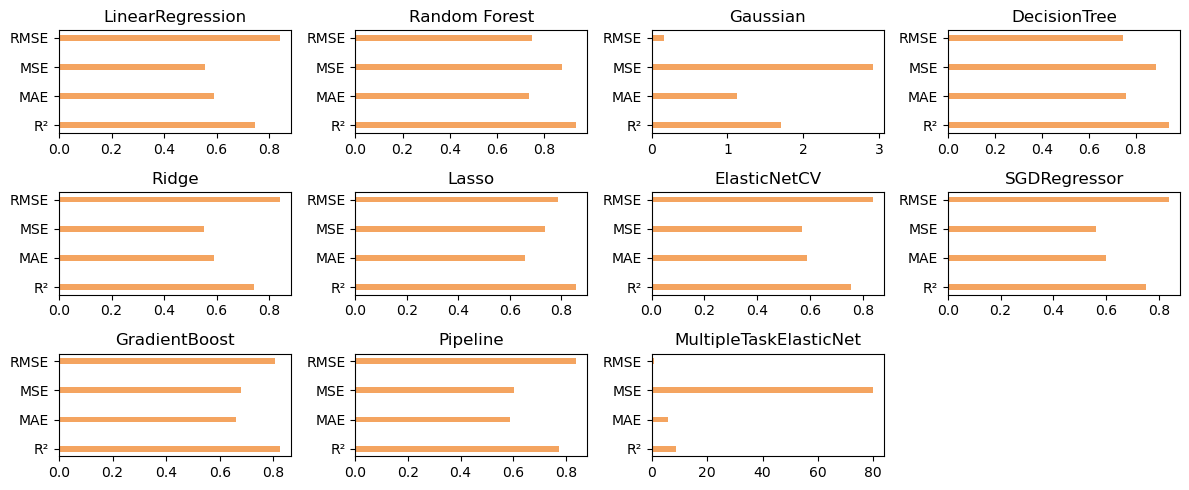

In [66]:
#display the performance numbers of all used modes

fig, ax=plt.subplots(3, 4, figsize=(12,5))
ax=ax.flatten()
for i, (n,e, m, a,r)  in enumerate(zip(names, r2_all, mse_all, mae_all, rmse_all)):
    ax[i].barh(['RMSE', 'MSE', 'MAE','R²'],[e, m, a,r], height=0.2, color='sandybrown')
    ax[i].invert_yaxis()
    ax[i].set_title(n)

#hide redundant figure
for j in range(i + 1, len(ax)):
    ax[j].set_visible(False)
    
plt.tight_layout()
#plt.savefig('/Users/libraryfree/Desktop/MachineLearning/CausalInf_project/model_performances.jpeg')
plt.show()

    

In [58]:
# Comparison of Coefficients
models=[model, model5, model6, model7, model8]
names=['LinearRegression', 'Ridge', 'Lasso','ElasticNetCV', 'SGDRegressor']
print('Coefficents and Bias for\n')
for m, n in zip(models,  names):
    print(f'{n}:\n{m.coef_}')
    print(f'bias: {m.intercept_}\n')

Coefficents and Bias for

LinearRegression:
[ 0.31566347  0.30763768  0.0641362  -0.30955148  0.0233373  -0.06335165
  0.01819693]
bias: -1.5791186344941703

Ridge:
[ 0.16123901  0.88388943  1.44928235 -0.29629476  0.19672817 -0.81109274
  0.01912453]
bias: 5.768593641960233

Lasso:
[ 0.          0.          0.10460567 -0.          0.         -0.09553967
  0.        ]
bias: 0.5002573038074392

ElasticNetCV:
[ 0.15726815  0.27974348  0.06962821 -0.08039489  0.00158684 -0.07095698
  0.        ]
bias: 0.35938667022077997

SGDRegressor:
[ 0.19139707  1.19382728  0.84197506 -0.19336009  0.12431623 -0.44358072
  0.02610286]
bias: [5.76857257]



In [ ]:
#visualize coefficients
models=[model, model5, model6, model7, model8]
names=['LinearRegression', 'Ridge', 'Lasso','ElasticNetCV', 'SGDRegressor']
for m,n in zip(models, names):
    

## Preliminary Results
Gaussian Process Regressor delivers significantly worse results than the other models: a strongly increased MSE≈13 as well as an R² below 0 (≈-3). After adding the random noise feature, these values improve slightly (MSE≈4, R²≈-1), because this model treats all inputs as equally important and does not distinguish between relevant and irrelevant features for the target.

The other models show no major changes in MSE and R² after adding the noise feature, which indicates their stability on this dataset and identifies this last feature as a good correction/control feature.
However, the bias/intercept of b≈-1 in the Linear Regression model already represents a deviation from reality, since coping should not become negative without the influence of the six features. Therefore, this model is not selected.

Since the Lasso Regression model sets entire features to 0 and only considers mental health and cognitive score for prediction, it achieves good results, but oversimplifies the problem by ignoring other aspects of socioeconomic life.
Ridge Regression produces the same MSE and R² values as the Linear Regression model because, after examining the coefficients, it performs almost exactly the same calculation. Therefore, no strongly dominant features appear to exist. After scaling, the coefficients of some features (e.g. the first two features) increased slightly and aligned more closely with the trend of the other models. Scaling therefore led to more accurate interpretations.

Elastic Net is highly trustworthy, because it is the only model that sets random noise to 0, meaning this feature is ignored for prediction exactly as expected from the dataset design.
When Using the MultiTask version, the MSE of 80 shows, that the features are not connected, and therefore no prediction in common relation is possible.

Random Forest Regressor was expected to react very well to this complex problem. Since it does not outperform the simpler linear models, the parameters apparently do not depend on each other as strongly as expected. From around 55 trees onward, no major changes can be observed (even up to 200 trees), which indicates sufficient model learning. Fine-tuning the parameters did not achieve major improvements, so the model only performs moderately on this dataset.
The Decision Tree Regressor improves quickly through fine-tuning (max_depth=4) and performs better than the Forest model.
The Gradient Boosting Regressor model also performs better than both the Forest and the DecisionTreeRegressor.

The trial-and-error model SGD Regressor performed surprisingly well and is therefore considered as a final candidate. The main difference compared to ElasticNetCV is the large difference in bias/intercept values:
average SGD bias ≈ 5, ElasticNet bias ≈ 0.3
Thus, the final candidates are:

Gradient Boosting, ElasticNetCV, SGD

Since all three produce very similar evaluation values, the final prediction is no longer strongly dependent on the exact model choice.
Final selection:
Elastic Net, because it sets random noise to 0 and achieves the best evaluation metrics (MSE, RMSE, MAE).

In [59]:
#fig, ax=plt.subplots(3,1, figsize=(15,12))
#plt.title("Different Models")
# perfect prediction line
for i in range(3):
    ax[i].plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], color='black', linestyle='--')

# different models
#models=[model, model2, model3, model4, model5, model6, model7, model8, model9, model10,model12]
#names=['LinearRegression', 'Random Forest', 'Gaussian','DecisionTree', 'Ridge', 'Lasso','ElasticNetCV', 'SGDRegressor','GradientBoost', 'Pipeline', 'MultipleTaskElasticNet']
#xtest=[x_test, x2_test, x3_test, x4_test, x5_test, x6_test, x7_test, x8_test, x9_test, x10_test, x12_test] #, x11_test,
#ytest=[y_test, y2_test, y3_test, y4_test, y5_test, y6_test, y7_test, y8_test, y9_test, y10_test, y12_test] #, y11_test,
#xtrain=[x_train, x2_train, x3_train, x4_train, x5_train, x6_train, x7_train, x8_train, x9_train, x10_train, x12_train] #, x11_train

#skaliert: 3,5,10, (11)
models1=[model3, model5, model10]
names1=['Gaussian', 'Ridge', 'Pipeline']
xtest1=[x3_test, x5_test,  x10_test] #, x11_test,
ytest1=[y3_test, y5_test, y10_test] #, y11_test,
xtrain1=[x3_train, x5_train,   x10_train] #, x11_train
for xt,xtr, yt,n,m in zip(xtest1, xtrain1,ytest1,names1, models1):
    ax[0].scatter(yt, m.predict(xt), label=n)
ax[0].set_title('scaled')
ax[0].legend(loc='lower right')

#not scaled
models2=[model, model2, model4,  model7, model8, model12]
names2=['LinearRegression', 'Random Forest', 'DecisionTree', 'ElasticNetCV', 'SGDRegressor', 'MultipleTaskElasticNet']
xtest2=[x_test, x2_test, x4_test,  x7_test, x8_test,  x12_test] #, x11_test,
ytest2=[y_test, y2_test, y4_test, y7_test, y8_test, y12_test] #, y11_test,
xtrain2=[x_train, x2_train, x4_train, x7_train, x8_train, x12_train] #, x11_train

for xt,xtr, yt,n,m in zip(xtest2, xtrain2,ytest2,names2, models2):
    ax[1].scatter(yt, m.predict(xt), label=n)
ax[1].set_title('not scaled')
ax[1].legend(loc='lower right')


#out of range: 
models3=[model6, model9]
names3=['Lasso','GradientBoost']
xtest3=[x6_test,  x9_test] #, x11_test,
ytest3=[y6_test, y9_test] #, y11_test,
xtrain3=[x6_train, x9_train] #, x11_train
for xt,xtr, yt,n,m in zip(xtest3, xtrain3,ytest3,names3, models3):
    ax[2].scatter(yt, m.predict(xt), label=n)
ax[2].set_title('other range')
ax[2].legend(loc='lower right')

plt.tight_layout()
#plt.show()

TypeError: 'Axes' object is not subscriptable

/Users/libraryfree/miniconda3/envs/sky/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianProcessRegressor was fitted without feature names
  warnings.warn(
/Users/libraryfree/miniconda3/envs/sky/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/Users/libraryfree/miniconda3/envs/sky/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SGDRegressor was fitted without feature names
  warnings.warn(


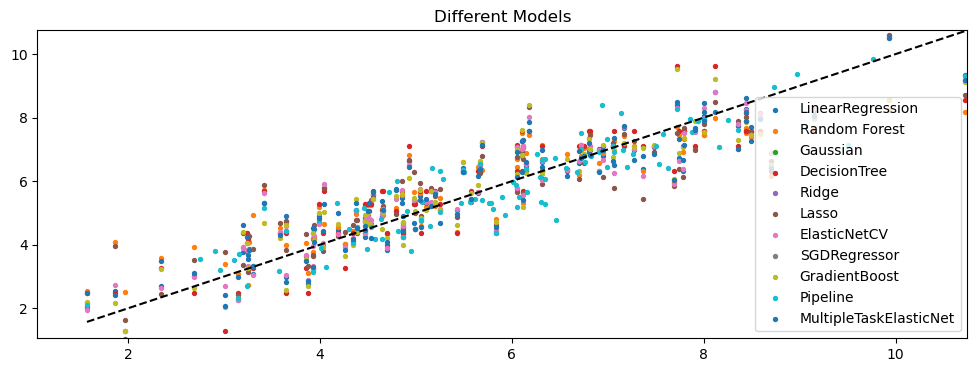

In [44]:
fig, ax= plt.subplots(1,1,figsize=(12,4))
ax.set_title("Different Models")
# perfect prediction line
ax.plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], color='black', linestyle='--')
# different models
models=[model, model2, model3, model4, model5, model6, model7, model8, model9, model10,model12]
names=['LinearRegression', 'Random Forest', 'Gaussian','DecisionTree', 'Ridge', 'Lasso','ElasticNetCV', 'SGDRegressor','GradientBoost', 'Pipeline', 'MultipleTaskElasticNet']
xtest=[x_test, x2_test, x3_test, x4_test, x5_test, x6_test, x7_test, x8_test, x9_test, x10_test, x12_test] #, x11_test,
ytest=[y_test, y2_test, y3_test, y4_test, y5_test, y6_test, y7_test, y8_test, y9_test, y10_test, y12_test] #, y11_test,
xtrain=[x_train, x2_train, x3_train, x4_train, x5_train, x6_train, x7_train, x8_train, x9_train, x10_train, x12_train] #, x11_train
for xt,xtr, yt,n,m in zip(xtest, xtrain,ytest,names, models):
    plt.scatter(yt, m.predict(xt), label=n, s=8)
plt.legend(loc='lower right')
#fit all models to same values, if too far off, clip their values
q_low  = np.percentile(y_test, 1)
q_high = np.percentile(y_test, 99)
margin = (q_high - q_low) * 0.1
plt.xlim(q_low - margin, q_high + margin)
plt.ylim(q_low - margin, q_high + margin)

plt.show()
